## Plot function for "Isolate Label Skew Effects"

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_label_skew_metric(
    csv_path,
    metric="f1_global_macro",
    beta_q=10.0,
    save_path=None,
):
    """
    Plot performance as a function of beta_L while keeping beta_Q fixed.

    Parameters
    ----------
    csv_path : str
        Path to the summary csv.
    metric : str
        One of:
        - "f1_global_macro"
        - "f1_per_client_macro"
        - "mse_macro"
        - "ece_macro"
    beta_q : float
        Fixed beta_Q value used to isolate label skew effects.
    save_path : str or None
        Optional path to save the figure.
    """

    df = pd.read_csv(csv_path)

    # Filter to isolate label skew effects
    df = df[df["beta_Q"] == beta_q].copy()

    if df.empty:
        raise ValueError(f"No rows found with beta_Q = {beta_q}")

    metric_map = {
        "f1_global_macro": [
            "F1_global_AlveolarOsteitis",
            "F1_global_SecondaryInfection",
            "F1_global_NerveDysesthesia",
            "F1_global_Bleeding",
        ],
        "f1_per_client_macro": [
            "F1_per_client_AlveolarOsteitis",
            "F1_per_client_SecondaryInfection",
            "F1_per_client_NerveDysesthesia",
            "F1_per_client_Bleeding",
        ],
        "mse_macro": [
            "MSE_AlveolarOsteitis",
            "MSE_SecondaryInfection",
            "MSE_NerveDysesthesia",
            "MSE_Bleeding",
        ],
        "ece_macro": [
            "ECE_AlveolarOsteitis",
            "ECE_SecondaryInfection",
            "ECE_NerveDysesthesia",
            "ECE_Bleeding",
        ],
    }

    if metric not in metric_map:
        raise ValueError(
            f"Unknown metric '{metric}'. Choose one of: {list(metric_map.keys())}"
        )

    cols = metric_map[metric]

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in csv: {missing}")

    # Macro average across complications
    df["plot_metric"] = df[cols].mean(axis=1)

    # Sort values for clean plotting
    df = df.sort_values(["paradigm", "beta_L"])

    ylabel_map = {
        "f1_global_macro": "Macro F1 (global)",
        "f1_per_client_macro": "Macro F1 (per client)",
        "mse_macro": "Macro MSE",
        "ece_macro": "Macro ECE",
    }

    print(df[df["paradigm"]=="local"][["beta_L","plot_metric"]])
    print(df[df["paradigm"]=="centralized"][["beta_L","plot_metric"]])
    plt.figure(figsize=(8, 5))

    for paradigm in df["paradigm"].dropna().unique():
        sub = df[df["paradigm"] == paradigm].sort_values("beta_L")
        plt.plot(sub["beta_L"], sub["plot_metric"], marker="o", label=paradigm)

    plt.xlabel(r"Label skew $\beta_L$")
    plt.ylabel(ylabel_map[metric])
    plt.title(f"{ylabel_map[metric]} vs. $\\beta_L$ (with $\\beta_Q={beta_q}$)")
    plt.legend(title="Paradigm")
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

     beta_L  plot_metric
16      0.1          NaN
34      0.5          NaN
52      1.0          NaN
70      1.5          NaN
88      2.0          NaN
106    10.0          NaN
     beta_L  plot_metric
15      0.1     0.610802
33      0.5     0.622685
51      1.0     0.702837
69      1.5     0.748465
87      2.0     0.758528
105    10.0     0.772093


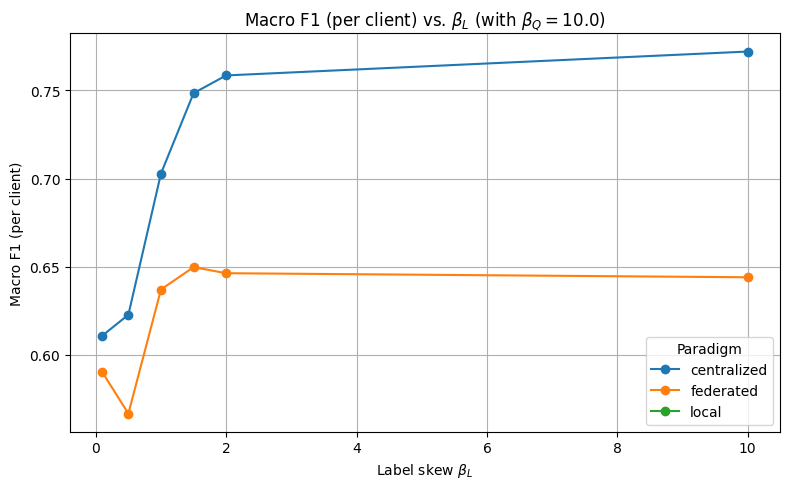

In [15]:
csv_path = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Results\sweep_beta_summary_1.csv"
plot_label_skew_metric(csv_path, metric="f1_per_client_macro", beta_q=10.0)

In [19]:
df = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Results\sweep_beta_summary.csv")

df.head()

,paradigm,beta_L,beta_Q,seed,f1_global_macro,f1_per_client_macro,mse_macro,ece_macro,MSE_AlveolarOsteitis,ECE_AlveolarOsteitis,...,F1_global_SecondaryInfection,F1_per_client_SecondaryInfection,F1_global_NerveDysesthesia,F1_per_client_NerveDysesthesia,F1_global_Bleeding,F1_per_client_Bleeding,disagreement_per_client_macro,disagreement_global_macro,fleiss_kappa_per_client_macro,fleiss_kappa_global_macro
0,centralized,0.1,0.1,42,0.760533,0.608790,0.000296,0.002131,0.000672,0.003536,...,0.824621,0.656353,0.650150,0.568571,0.735156,0.588772,0.744667,0.000000,0.483297,1.000000
1,local,0.1,0.1,42,0.341427,0.412908,0.068111,0.150071,0.066107,0.156788,...,0.381430,0.440311,0.254769,0.361845,0.325651,0.393628,0.999667,0.997667,0.156900,0.103916
2,federated,0.1,0.1,42,0.621722,0.590322,0.000582,0.007005,0.001424,0.018423,...,0.733918,0.638312,0.439118,0.543393,0.600650,0.566038,0.727917,0.000000,0.483934,1.000000


In [16]:
df.columns

Index(['paradigm', 'beta_L', 'beta_Q', 'seed', 'MSE_AlveolarOsteitis',
       'ECE_AlveolarOsteitis', 'MSE_SecondaryInfection',
       'ECE_SecondaryInfection', 'MSE_NerveDysesthesia',
       'ECE_NerveDysesthesia', 'MSE_Bleeding', 'ECE_Bleeding',
       'F1_global_AlveolarOsteitis', 'F1_per_client_AlveolarOsteitis',
       'F1_global_SecondaryInfection', 'F1_per_client_SecondaryInfection',
       'F1_global_NerveDysesthesia', 'F1_per_client_NerveDysesthesia',
       'F1_global_Bleeding', 'F1_per_client_Bleeding',
       'disagreement_per_client_macro', 'disagreement_global_macro',
       'fleiss_kappa_per_client_macro', 'fleiss_kappa_global_macro'],
      dtype='object')